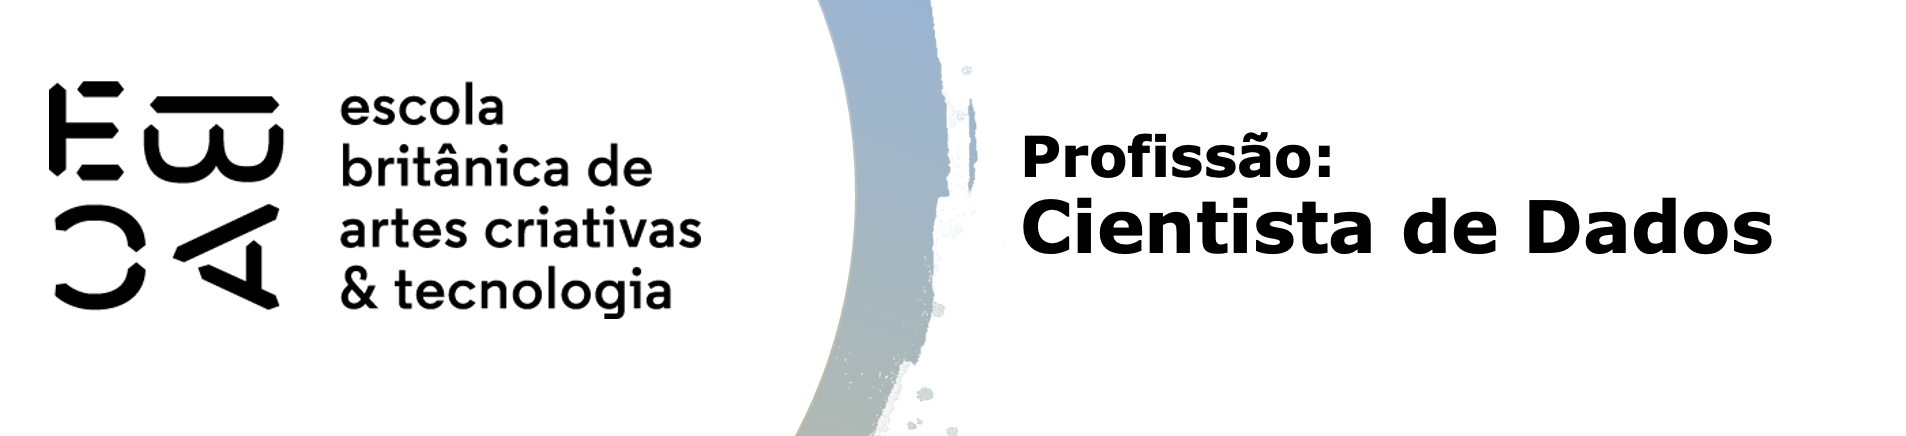

# Árvores II - Tarefa 3

### 1. Carregar as bases

Vamos utilizar nesta tarefa as bases de reconhecimento de atividade humana através do celular. Carregue novamente as bases salvas na tarefa I.

In [94]:
import pandas as pd  # Biblioteca para manipulação de dados em DataFrames
import seaborn as sns  # Biblioteca para visualização de dados estatísticos
import matplotlib.pyplot as plt  # Biblioteca para criação de gráficos
import numpy as np  # Biblioteca para operações matemáticas e manipulação de arrays

# Importação da árvore de decisão para classificação
from sklearn.tree import DecisionTreeClassifier  

# Função para dividir os dados em treino e teste
from sklearn.model_selection import train_test_split  

# Importação de métricas para avaliar o modelo
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay  

# Importação do GridSearchCV para otimização de hiperparâmetros
from sklearn.model_selection import GridSearchCV  

In [95]:
# Carrega os dados de treino e teste a partir de arquivos CSV
dataframe_treino = pd.read_csv('./input/Planilhas/Dataframe Treino.csv')
dataframe_teste = pd.read_csv('./input/Planilhas/Dataframe Teste.csv')

# Define um filtro com as colunas selecionadas para o modelo
filtro_de_colunas = ['53 tGravityAcc-min()-X', '272 fBodyAcc-mad()-X', '560 angle(Y,gravityMean)']

# Separa as variáveis independentes (X) e dependente (y) para o conjunto de treino
X_train = dataframe_treino.drop(columns=['Atividades'])  # Remove a coluna alvo
X_train = X_train[filtro_de_colunas]  # Mantém apenas as colunas selecionadas
y_train = dataframe_treino['Atividades']  # Define a variável alvo (y)

# Separa as variáveis independentes (X) e dependente (y) para o conjunto de teste
X_test = dataframe_teste.drop(columns=['Atividades'])  # Remove a coluna alvo
X_test = X_test[filtro_de_colunas]  # Mantém apenas as colunas selecionadas
y_test = dataframe_teste['Atividades']  # Define a variável alvo (y)


### 2. Calcule os ```ccp_alphas```. 

Vamos seguir uma lógica bem em linha com o que já estamso acostumados, com as seguintes orientações:

- Utilizar treinamento e teste conforme já vieram definidos originalmente
- Por pragmatismo, utilizar ```min_samples_leaf=20```
- Utilize as mesmas "3 melhores variáveis" identificadas no exercício anterior.

In [96]:
# Inicializa o modelo de árvore de decisão com uma semente aleatória para reprodutibilidade
caminho = DecisionTreeClassifier(random_state=100).cost_complexity_pruning_path(X_train, y_train)

# Extrai os valores de ccp_alpha e impurities do caminho de poda da árvore de decisão
ccp_alphas, impurities = caminho.ccp_alphas, caminho.impurities

# Filtra os valores de ccp_alpha para serem apenas maiores ou iguais a zero (evita valores negativos)
ccp_alphas = np.unique(ccp_alphas[ccp_alphas >= 0])

# Lista para armazenar os modelos treinados com diferentes valores de ccp_alpha
clfs = []

# Itera sobre os valores de ccp_alpha e treina uma árvore de decisão para cada valor
for ccp_alpha in ccp_alphas:
    # Cria um modelo de árvore de decisão com o valor atual de ccp_alpha, uma amostra mínima de 20 folhas e uma semente aleatória
    clf = DecisionTreeClassifier(random_state=26608740, ccp_alpha=ccp_alpha, min_samples_leaf=20).fit(X_train, y_test)
    
    # Adiciona o modelo treinado à lista
    clfs.append(clf)

### 3. *Grid Search*

Vou deixar especificações iniciais mínimas, que visam limitar o tempo de máquina, pois um procedimento desses pode demorar muito tempo dependendo da especificação. Mas conforme você for ficando confortável com o tempo consumido pelo procedimento, pode fazer um algoritmo mais exaustivo, por exemplo, avaliando mais valores de ```ccp_alpha```.

- Meça o tempo
- Utilize a base de treinamento
- Utilize um *cross validation* do tipo *k-fold*, especifique k=10
- Você pode ler 1 a cada ```k``` valores para uma melhor varredura utilizando, por exemplo, ```ccp_alpha[::10]```
- Não se esqueça de limitar o número de variáveis

In [97]:
# Inicializa um classificador de árvore de decisão sem parâmetros específicos
clf0 = DecisionTreeClassifier()

# Define o grid de parâmetros para busca, incluindo valores de ccp_alpha a cada 10 elementos e um valor fixo para min_samples_leaf
grid_params0 = {'ccp_alpha': ccp_alphas[::10], 'min_samples_leaf': [20]}

# Configura o GridSearchCV para encontrar os melhores hiperparâmetros com validação cruzada de 10 dobras (cv=10)
# O verbose=100 permite ver informações sobre o progresso da busca
grid0 = GridSearchCV(estimator=clf0, param_grid=grid_params0, cv=10, verbose=100)

# Realiza o treinamento e a busca dos melhores parâmetros no conjunto de treino
grid0.fit(X_train, y_train)


Fitting 10 folds for each of 13 candidates, totalling 130 fits
[CV 1/10; 1/13] START ccp_alpha=0.0, min_samples_leaf=20........................
[CV 1/10; 1/13] END ccp_alpha=0.0, min_samples_leaf=20;, score=0.803 total time=   0.0s
[CV 2/10; 1/13] START ccp_alpha=0.0, min_samples_leaf=20........................
[CV 2/10; 1/13] END ccp_alpha=0.0, min_samples_leaf=20;, score=0.742 total time=   0.0s
[CV 3/10; 1/13] START ccp_alpha=0.0, min_samples_leaf=20........................
[CV 3/10; 1/13] END ccp_alpha=0.0, min_samples_leaf=20;, score=0.749 total time=   0.0s
[CV 4/10; 1/13] START ccp_alpha=0.0, min_samples_leaf=20........................
[CV 4/10; 1/13] END ccp_alpha=0.0, min_samples_leaf=20;, score=0.627 total time=   0.0s
[CV 5/10; 1/13] START ccp_alpha=0.0, min_samples_leaf=20........................
[CV 5/10; 1/13] END ccp_alpha=0.0, min_samples_leaf=20;, score=0.875 total time=   0.0s
[CV 6/10; 1/13] START ccp_alpha=0.0, min_samples_leaf=20........................
[CV 6/10; 1

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'ccp_alpha': array([0.        , 0.0003172 , 0.00033727, 0.00044417, 0.00056909,
       0.00063619, 0.00077561, 0.0009554 , 0.0011504 , 0.00167444,
       0.00252124, 0.00393909, 0.01898663]),
                         'min_samples_leaf': [20]},
             verbose=100)

### 4. Avaliando a árvore

- Obtenha a árvore na melhor configuração treinada em toda a base de treino
- Calcule a acurácia dessa árvore na base de testes
- Visualize a matriz de confusão

In [98]:
# Retorna a melhor pontuação de validação cruzada obtida durante a busca de hiperparâmetros
grid0.best_score_  # A melhor acurácia média obtida através do GridSearchCV

0.7536261962412083

In [99]:
# Retorna o melhor modelo (classificador) encontrado durante a busca de hiperparâmetros
grid0.best_estimator_  # O modelo com a melhor combinação de parâmetros obtidos


DecisionTreeClassifier(ccp_alpha=0.0016744360439496196, min_samples_leaf=20)

In [100]:
# Cria um novo classificador de árvore de decisão com os melhores parâmetros encontrados (ccp_alpha e min_samples_leaf)
melhor_arvore0 = DecisionTreeClassifier(ccp_alpha=0.001714500026789063, min_samples_leaf=20)

# Treina o modelo com os dados de treino (X_train, y_train) usando os parâmetros definidos
# Nota: o correto é usar y_train, e não y_test, para o treinamento
melhor_arvore0.fit(X_train, y_train)  # Ajusta o modelo com os dados de treino


DecisionTreeClassifier(ccp_alpha=0.001714500026789063, min_samples_leaf=20)

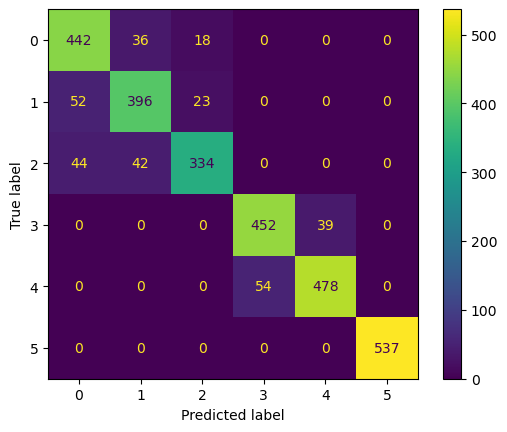

In [101]:
# Calcula a matriz de confusão para as predições no conjunto de teste
cm = confusion_matrix(y_test, melhor_arvore0.predict(X_test))

# Cria uma visualização da matriz de confusão
disp0 = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plota a matriz de confusão
disp0.plot()

In [102]:
# Cria um novo DataFrame 'dataframe_erros' a partir de X_test
dataframe_erros = (X_test.copy()  # Faz uma cópia de X_test para não alterar o DataFrame original
                   .assign(y_pred=melhor_arvore0.predict(X_test))  # Adiciona a coluna 'y_pred' com as previsões do modelo
                   .assign(y_true = y_test.values)  # Adiciona a coluna 'y_true' com os valores reais de y_test
                   .assign(ERROS = lambda df: df['y_pred'] != df['y_true']))  # Cria a coluna 'ERROS' onde é True quando a previsão é errada

# Cria uma tabela dinâmica (pivot_table) para contar os erros por classe real, 
# ordenada pela quantidade de erros (coluna 'ERROS') em ordem decrescente
dataframe_erros.pivot_table(values='ERROS', index=dataframe_erros['y_true'], aggfunc='sum').sort_values(ascending=False, by='ERROS')


,ERROS
y_true,
3,86
2,75
1,54
5,54
4,39
6,0


### 5. Melhorando a árvore

A melhor forma de se melhorar um algoritmo é colocando nele novas variáveis que agreguem valor. Podemos usar a força-bruta e ir colocando variáveis aleatoriamente - ou colocar todas e deixar rodando por um bom tempo - ou utilizar uma lógica eficiente e fazer uma seleção de variáveis.

- Observe que há classes mais fáceis e mais difíceis de se identificar
- Crie uma variável binária para uma das classes de maior erro
- Fala uma árvore de classificação bem simples para esta variável:
    - utilize ```mean_samples_leaf=20```
    - utilize ```max_depth=4```
    - coloque todas as variáveis
- Observe a importância das variáveis, e selecione as 3 com maior importância
- Rode novamente o algoritmo acima com as 3 novas variáveis e avalie a acurácia

In [103]:
# Cria uma nova coluna 'Atividade_maior_erro_flag' em dataframe_treino, onde a atividade com valor 3 é marcada como 1, caso contrário 0
dataframe_treino['Atividade_maior_erro_flag'] = [1 if x == 3 else 0 for x in dataframe_treino['Atividades']]

# Cria a mesma coluna 'Atividade_maior_erro_flag' em dataframe_teste com base nas atividades do conjunto de teste
dataframe_teste['Atividade_maior_erro_flag'] = [1 if x == 3 else 0 for x in dataframe_teste['Atividades']]

# Separa as variáveis independentes (X) e a variável dependente (y) para o conjunto de treino
X_train = dataframe_treino.drop(columns=['Atividades', 'Atividade_maior_erro_flag'])  # Remove as colunas 'Atividades' e 'Atividade_maior_erro_flag' de X_train
y_train = dataframe_treino['Atividade_maior_erro_flag']  # Define 'Atividade_maior_erro_flag' como a variável alvo para treino

# Separa as variáveis independentes (X) e a variável dependente (y) para o conjunto de teste
X_test = dataframe_teste.drop(columns=['Atividades', 'Atividade_maior_erro_flag'])  # Remove as colunas 'Atividades' e 'Atividade_maior_erro_flag' de X_test
y_test = dataframe_teste['Atividade_maior_erro_flag']  # Define 'Atividade_maior_erro_flag' como a variável alvo para teste

# Obtém o caminho de poda para a árvore de decisão com os dados de treino e a variável alvo 'y_train'
caminho = DecisionTreeClassifier(random_state=99785236, min_samples_leaf=20, max_depth=4).cost_complexity_pruning_path(X_train, y_train)

# Extrai os valores de ccp_alpha e impurities do caminho de poda
ccp_alphas, impurities = caminho.ccp_alphas, caminho.impurities

# Filtra os valores de ccp_alpha para serem apenas maiores ou iguais a zero
ccp_alphas = np.unique(ccp_alphas[ccp_alphas >= 0])

# Cria o classificador de árvore de decisão com uma semente aleatória para reprodutibilidade
clf1 = DecisionTreeClassifier(random_state=651498)

# Define o grid de parâmetros para o GridSearchCV, incluindo ccp_alpha, min_samples_leaf e max_depth
grid_params1 = {'min_samples_leaf': [20], 'max_depth': [4], 'ccp_alpha': ccp_alphas}

# Configura o GridSearchCV com validação cruzada de 10 dobras (cv=10) e um nível de verbosidade para monitoramento do processo
grid1 = GridSearchCV(estimator=clf1, param_grid=grid_params1, cv=10, verbose=100)

# Executa o treinamento e a busca pelos melhores parâmetros no conjunto de treino
grid1.fit(X_train, y_train)



Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV 1/10; 1/12] START ccp_alpha=0.0, max_depth=4, min_samples_leaf=20...........
[CV 1/10; 1/12] END ccp_alpha=0.0, max_depth=4, min_samples_leaf=20;, score=0.980 total time=   0.4s
[CV 2/10; 1/12] START ccp_alpha=0.0, max_depth=4, min_samples_leaf=20...........
[CV 2/10; 1/12] END ccp_alpha=0.0, max_depth=4, min_samples_leaf=20;, score=0.956 total time=   0.4s
[CV 3/10; 1/12] START ccp_alpha=0.0, max_depth=4, min_samples_leaf=20...........
[CV 3/10; 1/12] END ccp_alpha=0.0, max_depth=4, min_samples_leaf=20;, score=0.969 total time=   0.4s
[CV 4/10; 1/12] START ccp_alpha=0.0, max_depth=4, min_samples_leaf=20...........
[CV 4/10; 1/12] END ccp_alpha=0.0, max_depth=4, min_samples_leaf=20;, score=0.953 total time=   0.4s
[CV 5/10; 1/12] START ccp_alpha=0.0, max_depth=4, min_samples_leaf=20...........
[CV 5/10; 1/12] END ccp_alpha=0.0, max_depth=4, min_samples_leaf=20;, score=0.980 total time=   0.4s
[CV 6/10; 1/12] START ccp_a

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=651498),
             param_grid={'ccp_alpha': array([0.        , 0.00028998, 0.00050823, 0.00073376, 0.00077224,
       0.00152698, 0.00426373, 0.00436064, 0.0059758 , 0.01357792,
       0.0146978 , 0.16082172]),
                         'max_depth': [4], 'min_samples_leaf': [20]},
             verbose=100)

In [104]:
# Retorna os melhores parâmetros encontrados durante a busca no GridSearchCV
grid1.best_params_  # O dicionário com os melhores valores para os parâmetros de 'min_samples_leaf', 'max_depth' e 'ccp_alpha'


{'ccp_alpha': 0.0, 'max_depth': 4, 'min_samples_leaf': 20}

In [105]:
# Cria um novo classificador de árvore de decisão utilizando os melhores parâmetros encontrados (max_depth, min_samples_leaf e ccp_alpha)
# O ccp_alpha é definido como 0.0, significando que não haverá poda
melhor_arvore1 = DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=651498, ccp_alpha=0.0)

# Treina o modelo com os dados de treino (X_train, y_train) usando os parâmetros definidos
# Nota: o correto seria usar y_train, e não y_test, para o treinamento
melhor_arvore1.fit(X_train, y_train)  # Ajusta o modelo com os dados de treino


DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=651498)

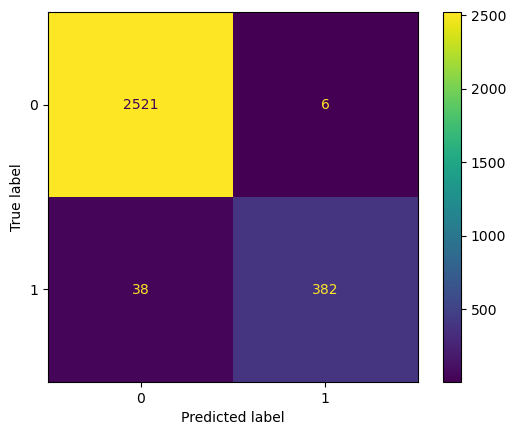

In [106]:
# Calcula a matriz de confusão comparando os valores reais (y_test) com as previsões feitas pelo modelo (melhor_arvore1)
cm = confusion_matrix(y_test, melhor_arvore1.predict(X_test))

# Cria um objeto para exibir a matriz de confusão de forma visual
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plota a matriz de confusão utilizando a função 'plot' do ConfusionMatrixDisplay
disp.plot()


In [107]:
# Cria um novo DataFrame 'df_erros' a partir de X_test
df_erros = (X_test.copy()  # Faz uma cópia de X_test para não alterar o DataFrame original
                   .assign(y_pred=melhor_arvore1.predict(X_test))  # Adiciona a coluna 'y_pred' com as previsões do modelo
                   .assign(y_true = y_test.values)  # Adiciona a coluna 'y_true' com os valores reais de y_test
                   .assign(ERROS = lambda df: df['y_pred'] != df['y_true']))  # Cria a coluna 'ERROS' onde é True quando a previsão é errada

# Cria uma tabela dinâmica (pivot_table) para contar os erros por classe real, 
# ordenada pela quantidade de erros (coluna 'ERROS') em ordem decrescente
df_erros.pivot_table(values='ERROS', index=df_erros['y_true'], aggfunc='sum').sort_values(ascending=False, by='ERROS')


,ERROS
y_true,
1,38
0,6


In [109]:
# Cria um DataFrame com as importâncias das características do modelo 'melhor_arvore1' e os nomes das variáveis em X_train
(
    pd.DataFrame(
        {
            "Importância": melhor_arvore1.feature_importances_,  # Obtém a importância de cada característica do modelo
            "Variável": X_train.columns,
        }
    )  # Associa as importâncias às variáveis em X_train
    .sort_values(
        ascending=False, by="Importância"
    )  # Ordena os resultados pela importância de forma decrescente
    .head(3)
)  # Exibe as 3 variáveis mais importantes

,Importância,Variável
506,0.729647,505 fBodyAccMag-mad()
420,0.091843,"419 fBodyAccJerk-bandsEnergy()-17,32"
476,0.066474,"475 fBodyGyro-bandsEnergy()-1,8"


In [110]:
# Define um filtro de colunas selecionadas para os dados de treino e teste
filtro_de_colunas = ['505 fBodyAccMag-mad()', '419 fBodyAccJerk-bandsEnergy()-17,32', '475 fBodyGyro-bandsEnergy()-1,8']

# Aplica o filtro de colunas no conjunto de treino, selecionando apenas as colunas especificadas em 'filtro_de_colunas'
X_train = X_train[filtro_de_colunas]

# Define 'y_train' como a coluna 'Atividades' do dataframe_treino (variável alvo)
y_train = dataframe_treino['Atividades']

# Aplica o filtro de colunas no conjunto de teste, selecionando apenas as colunas especificadas em 'filtro_de_colunas'
X_test = X_test[filtro_de_colunas]

# Define 'y_test' como a coluna 'Atividades' do dataframe_teste (variável alvo)
y_test = dataframe_teste['Atividades']

# Cria um classificador de árvore de decisão (DecisionTreeClassifier) com uma semente aleatória para reprodutibilidade
clf2 = DecisionTreeClassifier(random_state=26583310)

# Obtém o caminho de poda (ccp_alpha) para a árvore de decisão com os dados de treino e a variável alvo 'y_train'
caminho2 = DecisionTreeClassifier(random_state=26583310).cost_complexity_pruning_path(X_train, y_train)

# Extrai os valores de ccp_alpha e impurities do caminho de poda
ccp_alphas, impurities = caminho2.ccp_alphas, caminho2.impurities

# Filtra os valores de ccp_alpha para serem apenas maiores ou iguais a zero
ccp_alphas = np.unique(ccp_alphas[ccp_alphas >= 0])

# Define o grid de parâmetros para o GridSearchCV, incluindo ccp_alpha
grid_params2 = {'ccp_alpha': ccp_alphas}

# Configura o GridSearchCV com validação cruzada de 15 dobras (cv=15) e um nível de verbosidade para monitoramento do processo
grid2 = GridSearchCV(estimator=clf2, param_grid=grid_params2, cv=15, verbose=100)

# Executa o treinamento e a busca pelos melhores parâmetros no conjunto de treino
grid2.fit(X_train, y_train)


Fitting 15 folds for each of 271 candidates, totalling 4065 fits
[CV 1/15; 1/271] START ccp_alpha=0.0............................................
[CV 1/15; 1/271] END .............ccp_alpha=0.0;, score=0.477 total time=   0.0s
[CV 2/15; 1/271] START ccp_alpha=0.0............................................
[CV 2/15; 1/271] END .............ccp_alpha=0.0;, score=0.660 total time=   0.0s
[CV 3/15; 1/271] START ccp_alpha=0.0............................................
[CV 3/15; 1/271] END .............ccp_alpha=0.0;, score=0.599 total time=   0.0s
[CV 4/15; 1/271] START ccp_alpha=0.0............................................
[CV 4/15; 1/271] END .............ccp_alpha=0.0;, score=0.558 total time=   0.0s
[CV 5/15; 1/271] START ccp_alpha=0.0............................................
[CV 5/15; 1/271] END .............ccp_alpha=0.0;, score=0.650 total time=   0.0s
[CV 6/15; 1/271] START ccp_alpha=0.0............................................
[CV 6/15; 1/271] END .............ccp_alpha=

GridSearchCV(cv=15, estimator=DecisionTreeClassifier(random_state=26583310),
             param_grid={'ccp_alpha': array([0.        , 0.00022622, 0.0002545 , 0.00027146, 0.00028277,
       0.00028843, 0.00029085, 0.00029306, 0.00029691, 0.00029893,
       0.00030017, 0.00030163, 0.00030279, 0.00030848, 0.00030939,
       0.00031024, 0.00031105, 0.00031105, 0.00031323, 0.00031509,
       0.00031671, 0.00031695, 0.00031812,...
       0.0014802 , 0.00154005, 0.00156338, 0.00171115, 0.00176036,
       0.00185385, 0.00195277, 0.00203427, 0.00209414, 0.00213475,
       0.00233196, 0.0027138 , 0.00280035, 0.0028033 , 0.00282872,
       0.00283029, 0.00289905, 0.00379894, 0.00380413, 0.00381364,
       0.00501346, 0.00541217, 0.00640495, 0.00896663, 0.0089804 ,
       0.00916257, 0.01190514, 0.03516084, 0.04144073, 0.08884435,
       0.16102738])},
             verbose=100)

In [111]:
# Retorna a melhor pontuação de validação cruzada (score) obtida durante a busca do GridSearchCV
grid2.best_score_  # A melhor pontuação obtida para o modelo com os parâmetros definidos no grid


0.6107790324251527

In [112]:
# Retorna a melhor pontuação de validação cruzada (score) obtida durante a busca do GridSearchCV na primeira árvore gerada
grid0.best_score_  # A melhor pontuação obtida para o modelo com os parâmetros definidos no grid


0.7536261962412083

Resposta: As variáveis utilizadas na primeira seleção foram mais valiosas para realizar a predição das atividades, já que grid0 apresenta um score de acurácia superior a grid2